In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cleanGooglePlaystore.csv")

In [223]:
df.describe()

,Rating,Reviews,Size,Installs,isFree,Price,Content Rating_Adult,Content Rating_Everyone,Content Rating_Teen,Year Last Updated,...,Category_SOCIAL,Category_SPORTS,Category_TOOLS,Category_TRAVEL_AND_LOCAL,Category_VIDEO_PLAYERS,Category_WEATHER,Recently Updated,Highly_Installed,Highly_Rated,Highly_Reviewed
count,10840.000000,1.084000e+04,10840.000000,1.084000e+04,10840.000000,10840.000000,10840.000000,10840.000000,10840.000000,10840.000000,...,10840.000000,10840.000000,10840.000000,10840.000000,10840.000000,10840.000000,10840.000000,10840.000000,10840.000000,10840.000000
mean,4.191513,4.441529e+05,21.514505,1.546434e+07,0.926199,1.027368,0.046310,0.842251,0.111439,2017.399723,...,0.027214,0.035424,0.077768,0.023801,0.016144,0.007565,0.474539,0.456642,0.474170,0.256642
std,0.479412,2.927761e+06,20.748257,8.502936e+07,0.261458,15.949703,0.210165,0.364522,0.314690,1.100914,...,0.162714,0.184858,0.267818,0.152435,0.126035,0.086649,0.499374,0.498140,0.499355,0.436800
min,1.000000,0.000000e+00,0.008500,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,2010.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.100000,3.800000e+01,5.900000,1.000000e+03,1.000000,0.000000,0.000000,1.000000,0.000000,2017.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.200000,2.094000e+03,18.000000,1.000000e+05,1.000000,0.000000,0.000000,1.000000,0.000000,2018.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.500000,5.477550e+04,26.000000,5.000000e+06,1.000000,0.000000,0.000000,1.000000,0.000000,2018.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,5.000000,7.815831e+07,100.000000,1.000000e+09,1.000000,400.000000,1.000000,1.000000,1.000000,2018.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [145]:
correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

                                Rating   Reviews      Size  Installs  \
Rating                        1.000000  0.068024  0.075196  0.051260   
Reviews                       0.068024  1.000000  0.128258  0.643122   
Size                          0.075196  0.128258  1.000000  0.082230   
Installs                      0.051260  0.643122  0.082230  1.000000   
isFree                       -0.035765  0.041699  0.027175  0.051038   
Price                        -0.020142 -0.009667 -0.022986 -0.011689   
Content Rating_Adult         -0.028443 -0.003856  0.035721 -0.011547   
Content Rating_Everyone      -0.007622 -0.049212 -0.127908 -0.041073   
Content Rating_Teen           0.027825  0.059580  0.124306  0.055289   
Year Last Updated             0.127849  0.075537  0.206865  0.089368   
Month Last Updated            0.016350  0.045946  0.037931  0.056466   
Current Major Version         0.000072 -0.001060 -0.004685 -0.001049   
Android Major Version         0.051374  0.014646  0.134823  0.01

## LogReg Highly_Installed vs Highly_Rated

In [305]:
df['Recently_Updated'] = np.where((df['Year Last Updated'] > 2018) | 
                                   ((df['Year Last Updated'] == 2018) & (df['Month Last Updated'] >= 6)), 1, 0)

install_threshold = 500000
df['Highly_Installed'] = df['Installs'].apply(lambda x: 1 if x >= install_threshold else 0)

rating_threshold = 4.3
df['Highly_Rated'] = df['Rating'].apply(lambda x: 1 if x >= rating_threshold else 0)

review_threshold = 10000
df['Highly_Reviewed'] = df['Reviews'].apply(lambda x: 1 if x >= review_threshold else 0)

In [200]:
features = ['Highly_Installed']
target = 'Highly_Rated'

scaler = StandardScaler()
X = df[features]
X_scaled = scaler.fit_transform(X)

y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=43)


In [201]:
print(df[target].value_counts())

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

Highly_Rated
0    5700
1    5140
Name: count, dtype: int64


In [202]:
# Accuracy score
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.6223862238622386


In [203]:
# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[1092  600]
 [ 628  932]]


In [204]:
# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.65      0.64      1692
           1       0.61      0.60      0.60      1560

    accuracy                           0.62      3252
   macro avg       0.62      0.62      0.62      3252
weighted avg       0.62      0.62      0.62      3252



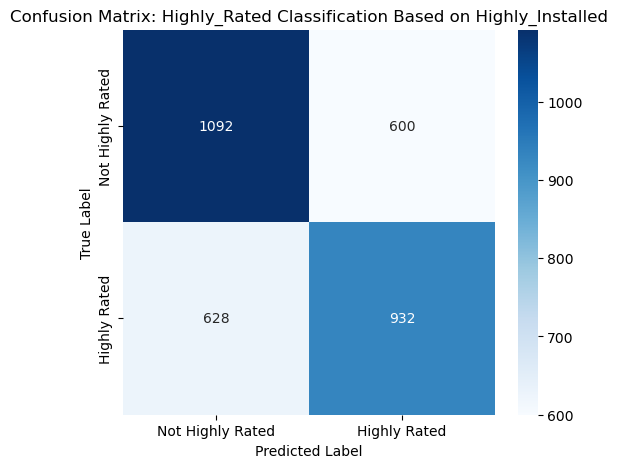

In [157]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Not Highly Rated', 'Highly Rated']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Highly_Rated Classification Based on Highly_Installed')

plt.savefig('CM_highly_rated_BASEDON_HighlyInstalled.png', dpi=300, bbox_inches='tight')

plt.show()

## LogReg Rating vs Reviews

In [272]:
features = ['Highly_Reviewed']
target = 'Highly_Rated'

X = df[features]
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Step 8: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=43)

print(df[target].value_counts())

# Step 9: Train the logistic regression model
#model = LogisticRegression(max_iter=1000)
#model.fit(X_train, y_train)

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# Step 10: Evaluate the model
y_pred = logreg.predict(X_test)


Highly_Rated
0    5700
1    5140
Name: count, dtype: int64


In [273]:
# Accuracy score
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6540590405904059
Confusion Matrix:
[[1240  452]
 [ 673  887]]


In [237]:
# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.73      0.69      1692
           1       0.66      0.57      0.61      1560

    accuracy                           0.65      3252
   macro avg       0.66      0.65      0.65      3252
weighted avg       0.66      0.65      0.65      3252



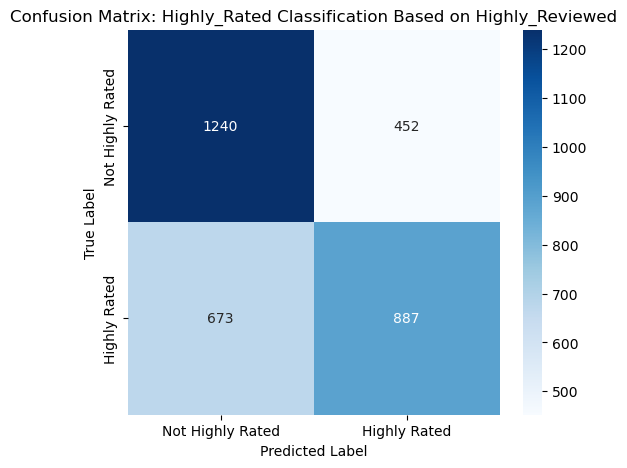

In [238]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Not Highly Rated', 'Highly Rated']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Highly_Rated Classification Based on Highly_Reviewed')

plt.savefig('CM_highly_rated_BASEDON_HighlyReviewed.png', dpi=300, bbox_inches='tight')

plt.show()

## Reviews vs Installs

In [278]:
features = ['Highly_Reviewed']
target = 'Highly_Installed'

X = df[features]
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=43)

print(df[target].value_counts())

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)


Highly_Installed
0    5890
1    4950
Name: count, dtype: int64


In [279]:
# Accuracy score
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9234317343173432
Confusion Matrix:
[[1692   28]
 [ 221 1311]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93      1720
           1       0.98      0.86      0.91      1532

    accuracy                           0.92      3252
   macro avg       0.93      0.92      0.92      3252
weighted avg       0.93      0.92      0.92      3252



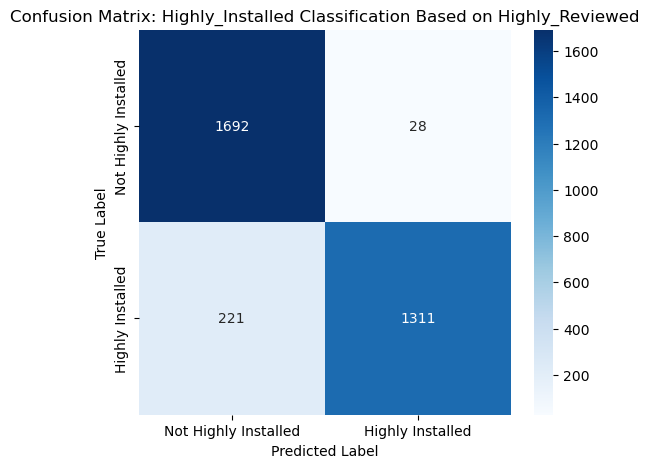

In [280]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Not Highly Installed', 'Highly Installed']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Highly_Installed Classification Based on Highly_Reviewed')

plt.savefig('CM_highly_installed_BASEDON_HighlyReviewed.png', dpi=300, bbox_inches='tight')

plt.show()

## LogReg Highly_Installed vs Recently Updated

In [255]:
features = ['Highly_Installed']
target = 'Recently_Updated'

X = df[features]
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=43)

print(df[target].value_counts())

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

Recently_Updated
0    5696
1    5144
Name: count, dtype: int64


In [256]:
# Accuracy score
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6722017220172202
Confusion Matrix:
[[1191  537]
 [ 529  995]]


In [257]:
# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.69      0.69      1728
           1       0.65      0.65      0.65      1524

    accuracy                           0.67      3252
   macro avg       0.67      0.67      0.67      3252
weighted avg       0.67      0.67      0.67      3252



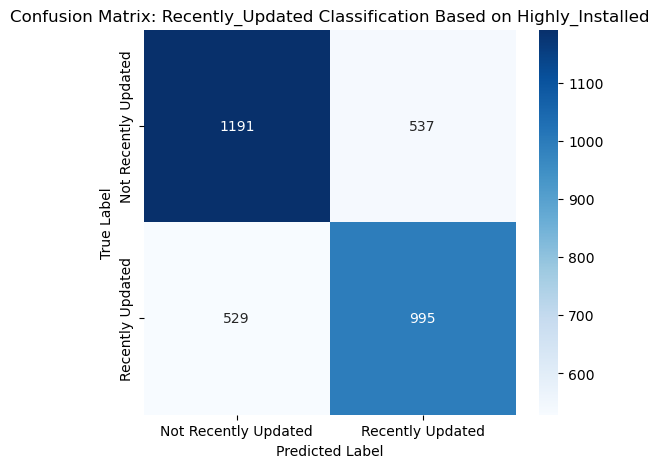

In [259]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Not Recently Updated', 'Recently Updated']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Recently_Updated Classification Based on Highly_Installed')

plt.savefig('CM_RecentlyUpdated_BASEDON_Highly Installed.png', dpi=300, bbox_inches='tight')

plt.show()

## LogReg Highly Rated Based on Recently Reviewed

In [306]:
features = ['Recently_Updated']
target = 'Highly_Reviewed'

X = df[features]
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=43)

print(df[target].value_counts())

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

Highly_Reviewed
0    6560
1    4280
Name: count, dtype: int64


In [307]:
# Accuracy score
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6872693726937269
Confusion Matrix:
[[1312  601]
 [ 416  923]]


In [308]:
# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.69      0.72      1913
           1       0.61      0.69      0.64      1339

    accuracy                           0.69      3252
   macro avg       0.68      0.69      0.68      3252
weighted avg       0.70      0.69      0.69      3252



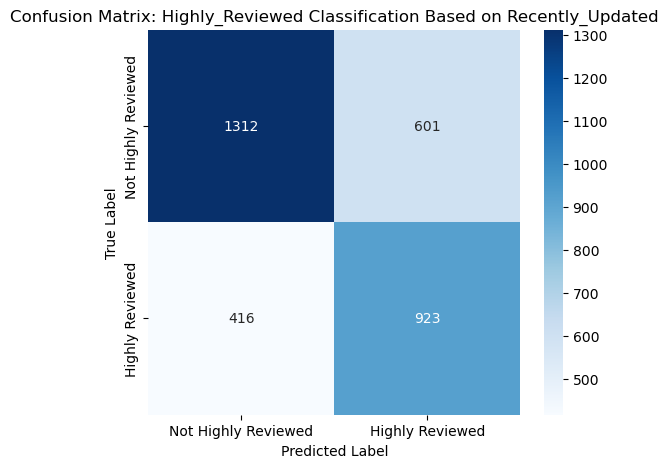

In [309]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Not Highly Reviewed', 'Highly Reviewed']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Highly_Reviewed Classification Based on Recently_Updated')

plt.savefig('CM_RecentlyUpdated_BASEDON_Highly Installed.png', dpi=300, bbox_inches='tight')

plt.show()

### Linear Regression

Mean Squared Error: 2.4950959974643676
R-squared: -0.029317555988743083


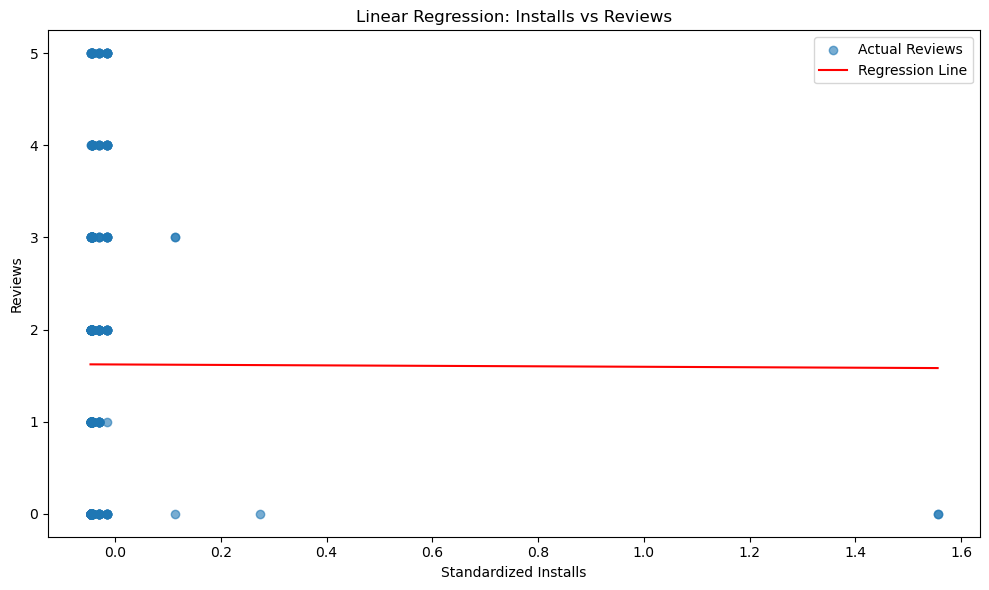

In [294]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

features = ['Installs']
target = 'Reviews'

df = df.dropna(subset=features + [target])
df = df[df['Reviews'] <= 5] 


X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Plot regression
X_plot = X_test_scaled.flatten()
sorted_idx = np.argsort(X_plot)
X_sorted = X_plot[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y_test, alpha=0.6, label='Actual Reviews')
plt.plot(X_sorted, y_pred_sorted, color='red', label='Regression Line')

plt.xlabel('Standardized Installs')
plt.ylabel('Reviews')
plt.title('Linear Regression: Installs vs Reviews')
plt.legend()
plt.tight_layout()

#plt.savefig("linear_regression_reviews_vs_installs.png", dpi=300)
plt.show()


## LinReg Installs vs Rating

Mean Squared Error: 0.21917017822655793
R-squared: 0.00334635006712225


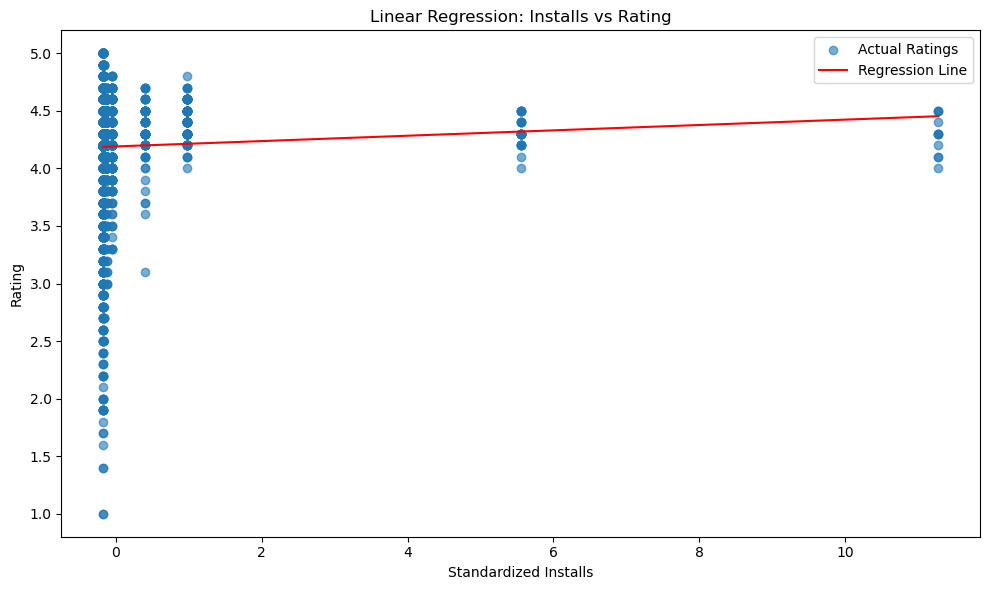

In [7]:
features = ['Installs']
target = 'Rating'

df = df.dropna(subset=features + [target])

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

X_plot = X_test_scaled.flatten()
sorted_idx = np.argsort(X_plot)
X_sorted = X_plot[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y_test, alpha=0.6, label='Actual Ratings')
plt.plot(X_sorted, y_pred_sorted, color='red', label='Regression Line')
plt.xlabel('Standardized Installs')
plt.ylabel('Rating')
plt.title('Linear Regression: Installs vs Rating')
plt.legend()
plt.tight_layout()
#plt.savefig("linear_regression_rating_vs_installs.png", dpi=300)
plt.show()


## Linreg Installs vs Reviews

Mean Squared Error: 1.8954721436353483
R-squared: 0.18242600913555385


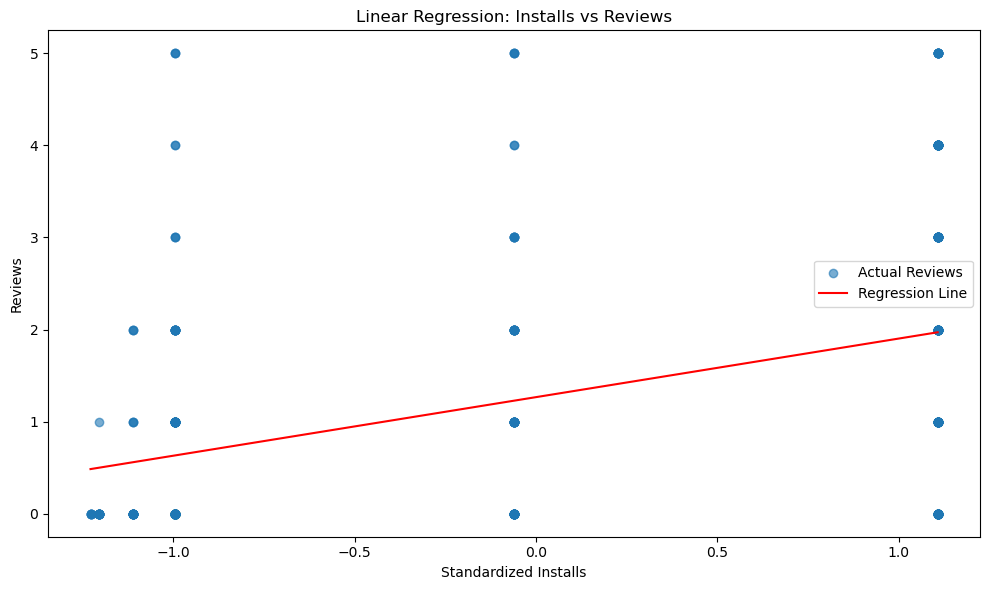

In [302]:
features = ['Installs']
target = 'Reviews'

df = df.dropna(subset=features + [target])

Q1 = df['Installs'].quantile(0.25)
Q3 = df['Installs'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Installs'] >= (Q1 - 1.5 * IQR)) & (df['Installs'] <= (Q3 + 1.5 * IQR))]

df = df[df['Reviews'] <= 5]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

X_plot = X_test_scaled.flatten()
sorted_idx = np.argsort(X_plot)
X_sorted = X_plot[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y_test, alpha=0.6, label='Actual Reviews')
plt.plot(X_sorted, y_pred_sorted, color='red', label='Regression Line')

plt.xlabel('Standardized Installs')
plt.ylabel('Reviews')
plt.title('Linear Regression: Installs vs Reviews')
plt.legend()
plt.tight_layout()

#plt.savefig("linear_regression_reviews_vs_installs_no_outliers.png", dpi=300)
plt.show()


In [267]:
print("Model Coefficients:")
print(model.coef_)

Model Coefficients:
[0.02327394]


Mean Squared Error: 0.9536806552635043
R-squared: 0.00334635006712225


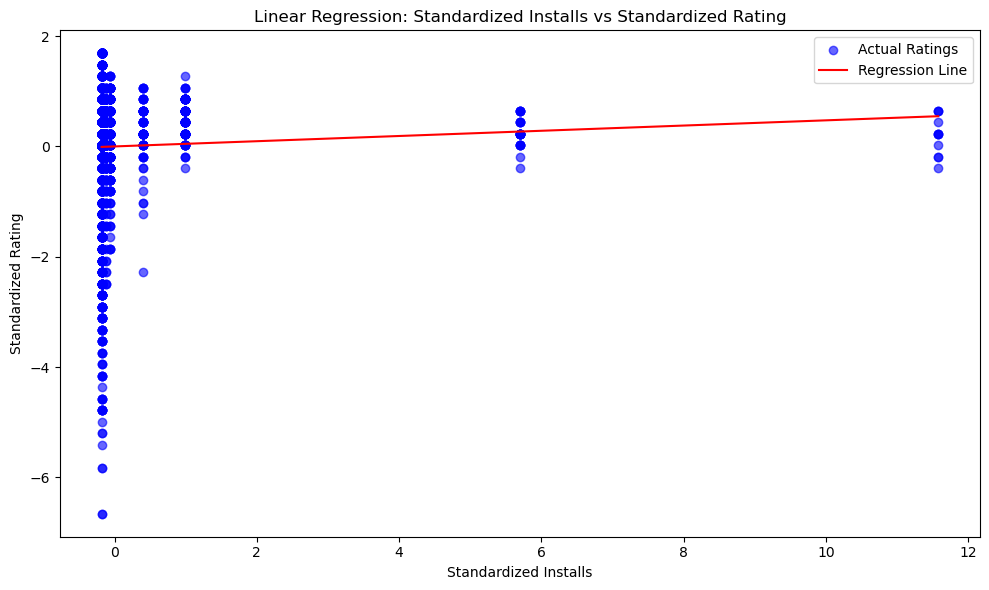

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Define features and target
features = ['Installs']
target = 'Rating'

# Step 2: Drop missing values
df = df.dropna(subset=features + [target])

# Step 3: Define X and y properly
X = df[features]  # 2D DataFrame
y = df[target]    # 1D Series

# Step 4: Standardize both features and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)  # Standardizing Installs
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # Standardizing Rating

# Step 5: Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Step 6: Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 7: Predict and evaluate
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Step 8: Plot the standardized data and regression line
X_plot = X_test.flatten()
sorted_idx = np.argsort(X_plot)
X_sorted = X_plot[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y_test, alpha=0.6, label='Actual Ratings', color='blue')
plt.plot(X_sorted, y_pred_sorted, color='red', label='Regression Line')

plt.xlabel('Standardized Installs')
plt.ylabel('Standardized Rating')
plt.title('Linear Regression: Standardized Installs vs Standardized Rating')
plt.legend()
plt.tight_layout()

# Save the plot
#plt.savefig("linear_regression_standardized_installs_vs_standardized_rating.png", dpi=300)
plt.show()


In [10]:
# Evaluation
y_pred = model.predict(X_test)
print("\nR-squared:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R-squared: 0.00334635006712225
MSE: 0.9536806552635043


## LinReg Installs vs Rating

In [6]:
df_clean = df.dropna(subset=['Installs', 'Rating'])

X = df_clean[['Installs']]
y = df_clean['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Coefficient (slope):", model.coef_[0])
print("Intercept:", model.intercept_)


Mean Squared Error: 0.21917017822655793
R-squared: 0.00334635006712225
Coefficient (slope): 0.02327393589179775
Intercept: 4.191210756039144
